By Justin

In [2]:
# Correlation Analysis for Tabular_1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Correct relative path (tabular_3 -> tabular_1)
file_path = "../tabular_1/diabetes_012_ready_to_model.csv"
label_col = "Diabetes_012"

# Load dataset
df_train = pd.read_csv(file_path)

print("Data shape:", df_train.shape)
print("Columns:", list(df_train.columns))


Data shape: (229712, 22)
Columns: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'GenHlth', 'Age', 'Education', 'Income', 'BMI', 'MentHlth', 'PhysHlth', 'Diabetes_012']


In [3]:
# Compute Pearson correlation with the label
corr_series = df_train.corr(numeric_only=True)[label_col].drop(label_col)

# Sort by absolute correlation value
corr_abs_sorted = corr_series.abs().sort_values(ascending=False)

# Display top 15 correlated features
print("\nTop 15 correlated features with label:")
print(corr_series.reindex(corr_abs_sorted.index[:15]))



Top 15 correlated features with label:
GenHlth                 0.282661
HighBP                  0.260295
BMI                     0.211328
DiffWalk                0.208574
HighChol                0.204321
Age                     0.185205
HeartDiseaseorAttack    0.167333
PhysHlth                0.159122
Income                 -0.148354
Education              -0.108992
PhysActivity           -0.102825
Stroke                  0.097857
CholCheck               0.076110
HvyAlcoholConsump      -0.065992
MentHlth                0.059169
Name: Diabetes_012, dtype: float64


C:\Users\zheng\AppData\Local\Temp\ipykernel_24756\964891111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


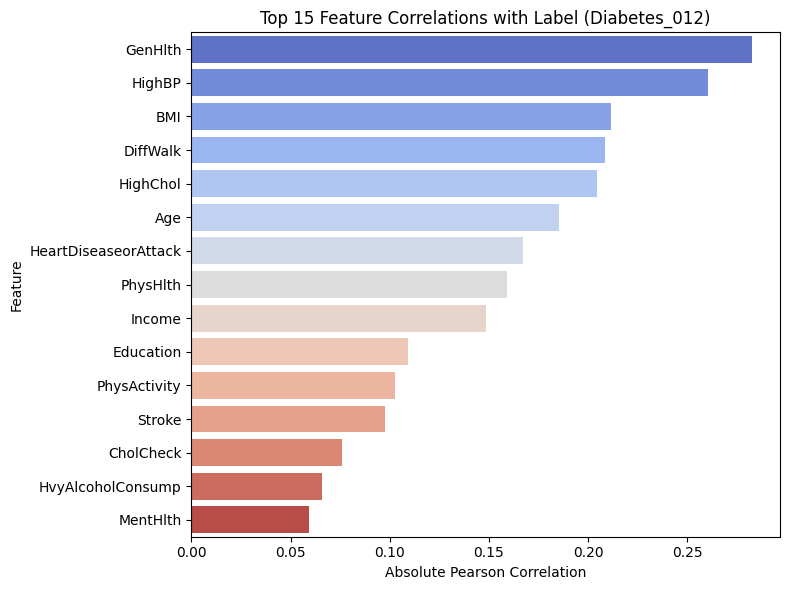

In [4]:
# Visualize top 15 absolute correlations
plt.figure(figsize=(8,6))
sns.barplot(
    x=corr_abs_sorted.values[:15],
    y=corr_abs_sorted.index[:15],
    palette="coolwarm"
)
plt.title("Top 15 Feature Correlations with Label (Diabetes_012)")
plt.xlabel("Absolute Pearson Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [5]:
# Select the final 8 template features and save 
# Prerequisite: corr_abs_sorted is already defined

# Core universal features that are almost always present across datasets
core_features = ["Age", "Sex", "BMI"]

# Take the top 10 features from correlation ranking
top_from_corr = list(corr_abs_sorted.index[:10])

# Merge and remove duplicates (keep order), then trim to 8 features
from collections import OrderedDict
merged = list(OrderedDict.fromkeys(core_features + top_from_corr))
mask_features = merged[:8]

print("Final 8 template features:", mask_features)

Final 8 template features: ['Age', 'Sex', 'BMI', 'GenHlth', 'HighBP', 'DiffWalk', 'HighChol', 'HeartDiseaseorAttack']


In [6]:
# Save the template as CSV and JSON for later alignment
import json
import pandas as pd
#from pathlib import Path


# out_dir = "tabular_feature_template_out.json"
# out_dir.mkdir(exist_ok=True)

# 1) Save as CSV (one column: feature)
pass

# 2) Save as JSON (with version, label name, and feature list)
features = mask_features
masks = []
for each_feature in features:
    masks.append(each_feature + "_mask")

template_meta = {"features": features, "masks": masks}
template_meta

{'features': ['Age',
  'Sex',
  'BMI',
  'GenHlth',
  'HighBP',
  'DiffWalk',
  'HighChol',
  'HeartDiseaseorAttack'],
 'masks': ['Age_mask',
  'Sex_mask',
  'BMI_mask',
  'GenHlth_mask',
  'HighBP_mask',
  'DiffWalk_mask',
  'HighChol_mask',
  'HeartDiseaseorAttack_mask']}

In [7]:
import os
os.getcwd()


'g:\\我的云端硬盘\\5703-Federated-Model\\Datasets\\tabular_template_building'

In [9]:
with open("tabular_feature_template.json", "w") as f:
    json.dump(template_meta, f, indent=4)

# print("Saved:", out_dir / "feature_template_v1.csv")
# print("Saved:", out_dir / "feature_template_v1.json")
